In [1]:
# Core libraries
import os
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications.vgg16 import VGG16

c:\Users\Workstation\Python Environments\mlenv\lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (6.0.0.post1)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


In [2]:
# Step: Download and locate the datasetimport kagglehub

# Download dataset
path = kagglehub.dataset_download("birendranathnandi/tea-leaves-pest-dataset")
print("Path to dataset files:", path)

def find_image_root(base_path):
    image_ext = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    for root, dirs, files in os.walk(base_path):
        if dirs:
            class_like_dirs = 0
            for directory in dirs:
                class_dir = os.path.join(root, directory)
                try:
                    has_image = any(file.lower().endswith(image_ext) for file in os.listdir(class_dir))
                except Exception:
                    has_image = False
                if has_image:
                    class_like_dirs += 1
            if class_like_dirs >= 2:
                return root
    return base_path

dataset_dir = find_image_root(path)
print("Dataset directory used:", dataset_dir)
print("Top-level entries:", os.listdir(dataset_dir)[:10])

Path to dataset files: C:\Users\Workstation\.cache\kagglehub\datasets\birendranathnandi\tea-leaves-pest-dataset\versions\1
Dataset directory used: C:\Users\Workstation\.cache\kagglehub\datasets\birendranathnandi\tea-leaves-pest-dataset\versions\1\TeaLeavesPest-Dataset\pest\test
Top-level entries: ['borer', 'caterpillar', 'grub', 'leafworm', 'mite', 'nematode', 'tea-aphid', 'tea-mosquito-bug', 'termite', 'thrip']


In [ ]:
# Step: Load dataset into training and test/validation setsimg_size = (224, 224)
batch_size = 32
validation_split = 0.2

datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=validation_split,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

train_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_classes = train_generator.num_classes
print("Number of classes:", num_classes)
print("Class indices:", train_generator.class_indices)

Found 480 images belonging to 10 classes.
Found 120 images belonging to 10 classes.
Number of classes: 10
Class indices: {'borer': 0, 'caterpillar': 1, 'grub': 2, 'leafworm': 3, 'mite': 4, 'nematode': 5, 'tea-aphid': 6, 'tea-mosquito-bug': 7, 'termite': 8, 'thrip': 9}


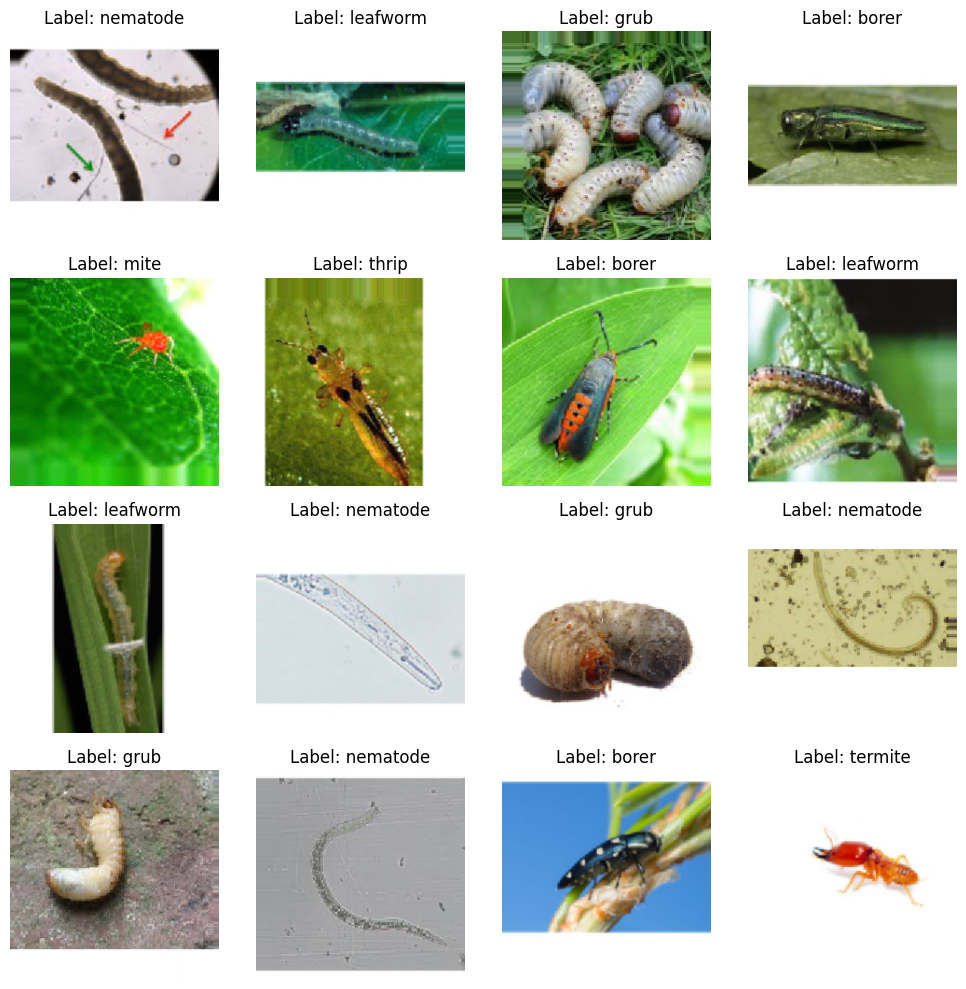

In [8]:
# Visualize sample images from training data
x_sample, y_sample = train_generator.next()

fig, axes = plt.subplots(4, 4, figsize=(10, 10))

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i, ax in enumerate(axes):
    image = x_sample[i]
    label = np.argmax(y_sample[i])
    
    # Get class name from class indices
    class_names = {v: k for k, v in train_generator.class_indices.items()}
    class_name = class_names.get(label, f"Class {label}")
    
    ax.imshow(image)
    ax.set_title(f"Label: {class_name}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [4]:
# Load VGG16 base model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Build transfer learning model
model = Sequential()
model.add(InputLayer(input_shape=(224, 224, 3)))
model.add(base_model)
model.add(GlobalAveragePooling2D())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 global_average_pooling2d (  (None, 512)               0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 256)               131328    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 10)                2570      
                                                                 
Total params: 14848586 (56.64 MB)
Trainable params: 133898 (523.04 KB)
Non-trainable params: 14714688 (56.13 MB)
_______

In [5]:
# Train model
epochs = 5
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,
    verbose=1
)

Epoch 1/5


15/15 [==============================] - 45s 3s/step - loss: 2.4401 - accuracy: 0.1021 - val_loss: 2.1883 - val_accuracy: 0.1833
Epoch 2/5
15/15 [==============================] - 40s 3s/step - loss: 2.2386 - accuracy: 0.1667 - val_loss: 2.0757 - val_accuracy: 0.3917
Epoch 3/5
15/15 [==============================] - 40s 3s/step - loss: 2.0450 - accuracy: 0.2979 - val_loss: 1.9651 - val_accuracy: 0.4333
Epoch 4/5
15/15 [==============================] - 43s 3s/step - loss: 1.9338 - accuracy: 0.3792 - val_loss: 1.8699 - val_accuracy: 0.5000
Epoch 5/5
15/15 [==============================] - 42s 3s/step - loss: 1.8528 - accuracy: 0.4125 - val_loss: 1.7784 - val_accuracy: 0.5250


In [6]:
# Evaluate model
val_loss, val_acc = model.evaluate(val_generator, verbose=2)
print('Validation accuracy:', val_acc)
print('Validation loss:', val_loss)

4/4 - 21s - loss: 1.7913 - accuracy: 0.4667 - 21s/epoch - 5s/step
Validation accuracy: 0.46666666865348816
Validation loss: 1.7913272380828857


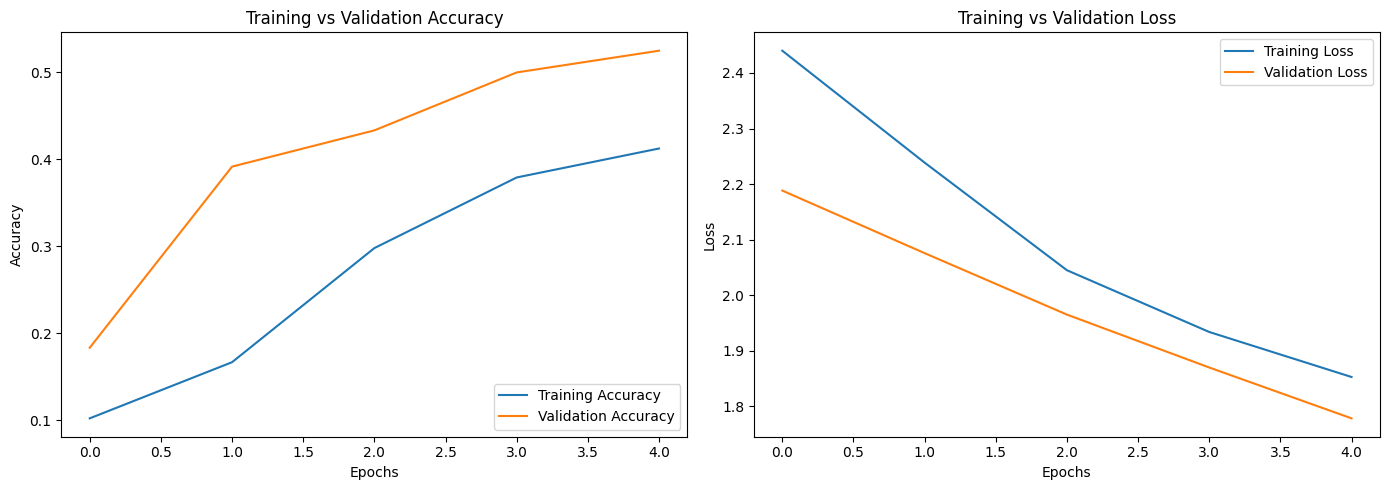

In [7]:
# Plot training history
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# Step: Execute this processing block